In [44]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [45]:
df = pd.read_csv("sustainability.csv", sep=',')

In [46]:
df['Country'] = df['Country'].astype('string')

df.set_index('Country', inplace=True)

df.head(2)

,People using safely managed drinking water services % of population 2017,People using safely managed sanitation services % of population 2017,Access to electricity % of population 2017,Renewable energy consumption % of total final energy consumption 2015,Expenditures for R&D % of GDP 2015,Urban population living in slums % of urban population 2014,Ambient PM2.5 air pollution mean annual exposure micrograms per cubic meter 2016,Adjusted net savings % of GNI 2017,Carbon dioxide emissions per capita metric tons 2014,Nationally protected terrestrial and marine areas % of total territorial area 2018,"Intentional homicides Combined source estimates per 100,000 people 2015",Internet use Individuals using the Internet % of population 2017
Country,,,,,,,,,,,,
Afghanistan,NaN,NaN,97.7,18.4,NaN,62.7,56.3,2.7,0.3,0.1,10.0,13.5
Albania,70.0,39.9,100.0,38.6,NaN,NaN,18.2,8.2,2.0,13.5,2.8,71.8


In [47]:
new_columns = [
    'Safe_Water',           # Доступ к чистой воде
    'Safe_Sanitation',      # Доступ к нормальной санитарии
    'Electricity_Access',   # Доступ к электричеству
    'Renewable_Energy',     # Потребление возобновляемой энергии
    'RD_Expenditure',       # Расходы на НИОКР (Науку)
    'Urban_Slums',          # Население в трущобах
    'Air_Pollution_PM25',   # Загрязнение воздуха (PM2.5)
    'Net_Savings',          # Чистые сбережения
    'CO2_Emissions',        # Выбросы CO2
    'Protected_Areas',      # Охраняемые природные территории
    'Homicide_Rate',        # Уровень убийств
    'Internet_Usage'        # Пользователи интернета
]

df.columns = new_columns

df.head(2)

,Safe_Water,Safe_Sanitation,Electricity_Access,Renewable_Energy,RD_Expenditure,Urban_Slums,Air_Pollution_PM25,Net_Savings,CO2_Emissions,Protected_Areas,Homicide_Rate,Internet_Usage
Country,,,,,,,,,,,,
Afghanistan,NaN,NaN,97.7,18.4,NaN,62.7,56.3,2.7,0.3,0.1,10.0,13.5
Albania,70.0,39.9,100.0,38.6,NaN,NaN,18.2,8.2,2.0,13.5,2.8,71.8


In [48]:
df = df.fillna(0)

In [49]:
df.tail(2)

,Safe_Water,Safe_Sanitation,Electricity_Access,Renewable_Energy,RD_Expenditure,Urban_Slums,Air_Pollution_PM25,Net_Savings,CO2_Emissions,Protected_Areas,Homicide_Rate,Internet_Usage
Country,,,,,,,,,,,,
Zambia,0.0,0.0,40.3,88.0,0.0,54.0,27.4,9.2,0.3,37.9,5.3,27.9
Zimbabwe,0.0,0.0,40.4,81.8,0.0,25.1,21.7,-22.2,0.9,27.2,6.7,27.1


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 214 entries, Afghanistan to Zimbabwe
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Safe_Water          214 non-null    float64
 1   Safe_Sanitation     214 non-null    float64
 2   Electricity_Access  214 non-null    float64
 3   Renewable_Energy    214 non-null    float64
 4   RD_Expenditure      214 non-null    float64
 5   Urban_Slums         214 non-null    float64
 6   Air_Pollution_PM25  214 non-null    float64
 7   Net_Savings         214 non-null    float64
 8   CO2_Emissions       214 non-null    float64
 9   Protected_Areas     214 non-null    float64
 10  Homicide_Rate       214 non-null    float64
 11  Internet_Usage      214 non-null    float64
dtypes: float64(12)
memory usage: 21.7+ KB


In [51]:
X = StandardScaler().fit_transform(df)
X

array([[-0.91231078, -0.76985952,  0.50136686, ..., -0.79286546,
         0.32417232, -1.32714597],
       [ 0.68795333,  0.25338423,  0.58962608, ...,  0.05559556,
        -0.2734404 ,  0.63926123],
       [-0.91231078, -0.31593936,  0.58962608, ..., -0.34963955,
        -0.38964287, -0.17361036],
       ...,
       [-0.91231078, -0.76985952, -0.20854423, ..., -0.76120646,
         0.05026649, -0.8819217 ],
       [-0.91231078, -0.76985952, -1.70127619, ...,  1.60055442,
        -0.06593598, -0.84144676],
       [-0.91231078, -0.76985952, -1.69743884, ...,  0.92305197,
         0.05026649, -0.86843005]], shape=(214, 12))

In [52]:
from sklearn.metrics import pairwise_distances
pd.DataFrame(pairwise_distances(X))

,0,1,2,3,4,5,6,7,8,9,...,204,205,206,207,208,209,210,211,212,213
0,0.000000,4.330610,3.405060,5.083588,5.774818,3.156593,3.873177,3.674202,3.996831,4.931133,...,4.191065,3.521503,4.114466,5.944317,2.812904,5.013460,3.683643,1.124467,4.433503,4.693940
1,4.330610,0.000000,2.879869,5.094792,2.272864,4.607087,2.705109,2.466393,1.576232,2.938970,...,2.300719,2.075539,2.783686,5.103978,2.482137,4.622813,2.455377,4.164734,4.575042,4.558149
2,3.405060,2.879869,0.000000,4.823600,4.300180,4.797237,2.495593,2.253868,3.017052,3.336148,...,2.947033,2.306868,2.898899,5.295795,1.922907,4.716230,2.234157,3.226977,5.050440,5.448391
3,5.083588,5.094792,4.823600,0.000000,6.079310,3.596153,4.756214,4.780429,5.167752,5.312561,...,5.035462,4.502380,3.446767,6.517752,4.886049,5.656685,4.926778,4.408940,4.638774,4.121004
4,5.774818,2.272864,4.300180,6.079310,0.000000,5.783619,3.916252,3.774941,2.194070,3.798294,...,4.173126,3.525328,4.594309,5.605058,4.302044,5.677436,3.379013,5.455379,5.778974,5.544325
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
209,5.013460,4.622813,4.716230,5.656685,5.677436,5.598818,3.409683,3.823623,4.941244,4.326810,...,4.014268,4.341115,5.040245,2.744472,4.637402,0.000000,4.507586,4.923489,6.309797,5.820224
210,3.683643,2.455377,2.234157,4.926778,3.379013,4.333295,2.206463,2.227098,2.572459,2.895194,...,2.808406,2.229440,3.502637,5.414831,2.343132,4.507586,0.000000,3.384987,5.267086,4.840022
211,1.124467,4.164734,3.226977,4.408940,5.455379,2.768849,3.455302,3.289832,3.760723,4.450591,...,4.136586,3.184686,3.863854,5.917348,2.721216,4.923489,3.384987,0.000000,4.358957,4.459570
212,4.433503,4.575042,5.050440,4.638774,5.778974,3.220173,5.380292,4.755248,4.743194,5.746885,...,4.321365,5.152560,4.078583,6.183782,4.041141,6.309797,5.267086,4.358957,0.000000,2.771347


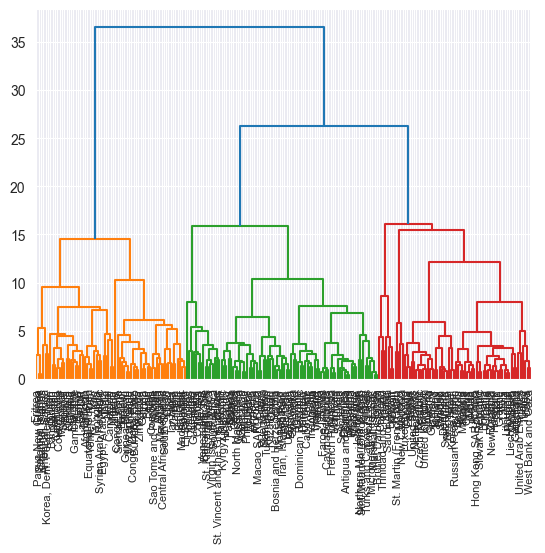

In [53]:
merging = linkage(X, method='ward')

dendrogram(merging, labels=df.index, leaf_rotation=90, leaf_font_size=8)
plt.show()

In [54]:
clusters = fcluster(merging, 30, criterion='distance')
print(clusters)

[1 2 2 1 2 1 2 2 2 2 2 2 2 2 2 1 2 2 2 2 1 2 1 1 2 2 2 2 2 1 1 2 1 1 2 2 1
 1 1 2 2 2 2 2 1 1 1 2 1 2 2 2 2 2 2 1 2 2 2 1 2 1 1 2 1 1 2 2 2 2 2 1 1 2
 2 1 2 2 2 2 2 1 1 2 1 2 2 2 1 2 2 1 2 2 2 2 2 2 2 2 1 2 1 2 2 2 2 1 2 2 2
 1 1 2 2 2 2 1 1 2 2 1 2 2 1 2 2 2 2 2 1 2 2 1 1 1 1 2 2 2 2 1 1 2 2 2 1 2
 2 1 2 2 2 2 2 2 2 2 2 1 2 2 1 2 1 2 2 1 2 2 2 2 1 1 2 1 2 2 2 2 2 2 1 2 2
 2 1 2 1 2 2 1 2 2 2 2 2 2 2 1 2 2 2 2 2 2 2 2 2 2 2 1 1 1]


In [55]:
df['label'] = clusters
print(df.sort_values('label')['label'])

Country
Afghanistan              1
American Samoa           1
Angola                   1
Bangladesh               1
Burundi                  1
                        ..
Vanuatu                  2
Uzbekistan               2
Vietnam                  2
West Bank and Gaza       2
Virgin Islands (U.S.)    2
Name: label, Length: 214, dtype: int32


In [56]:
kmeans = KMeans(n_clusters=3)
kmeans.fit(X)
labels = kmeans.predict(X)

dict(zip(df.index, labels))

{'Afghanistan': np.int32(2),
 'Albania': np.int32(1),
 'Algeria': np.int32(1),
 'American Samoa': np.int32(2),
 'Andorra': np.int32(1),
 'Angola': np.int32(2),
 'Antigua and Barbuda': np.int32(1),
 'Argentina': np.int32(1),
 'Armenia': np.int32(1),
 'Aruba': np.int32(1),
 'Australia': np.int32(1),
 'Austria': np.int32(1),
 'Azerbaijan': np.int32(1),
 'Bahamas, The': np.int32(1),
 'Bahrain': np.int32(1),
 'Bangladesh': np.int32(2),
 'Barbados': np.int32(1),
 'Belarus': np.int32(1),
 'Belgium': np.int32(1),
 'Belize': np.int32(1),
 'Benin': np.int32(2),
 'Bermuda': np.int32(1),
 'Bhutan': np.int32(1),
 'Bolivia': np.int32(1),
 'Bosnia and Herzegovina': np.int32(1),
 'Botswana': np.int32(1),
 'Brazil': np.int32(1),
 'Brunei Darussalam': np.int32(1),
 'Bulgaria': np.int32(1),
 'Burkina Faso': np.int32(2),
 'Burundi': np.int32(2),
 'Cabo Verde': np.int32(1),
 'Cambodia': np.int32(2),
 'Cameroon': np.int32(2),
 'Canada': np.int32(1),
 'Cayman Islands': np.int32(1),
 'Central African Republic

In [57]:
pd.Series(labels).value_counts().sort_index()

0      1
1    154
2     59
Name: count, dtype: int64

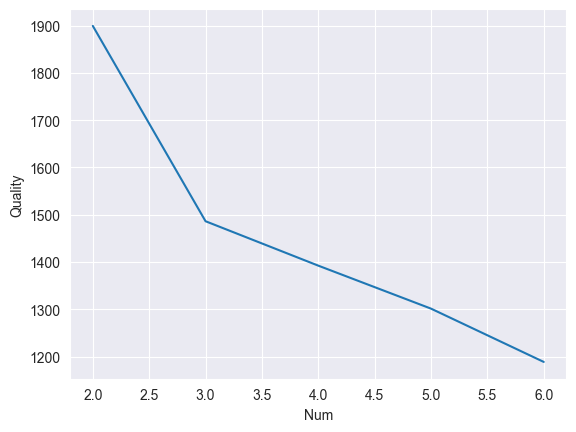

In [58]:
crit = []
for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=15)
    kmeans.fit(X)
    crit.append(kmeans.inertia_)

plt.plot(range(2,7), crit)
plt.xlabel('Num')
plt.ylabel('Quality')
plt.show()

In [59]:
kmeans = KMeans(n_clusters=3)
kmeans.fit(X)
labels = kmeans.predict(X)

pd.DataFrame(labels, df.index)

,0
Country,
Afghanistan,1
Albania,0
Algeria,0
American Samoa,1
Andorra,2
...,...
Virgin Islands (U.S.),0
West Bank and Gaza,0
"Yemen, Rep.",1


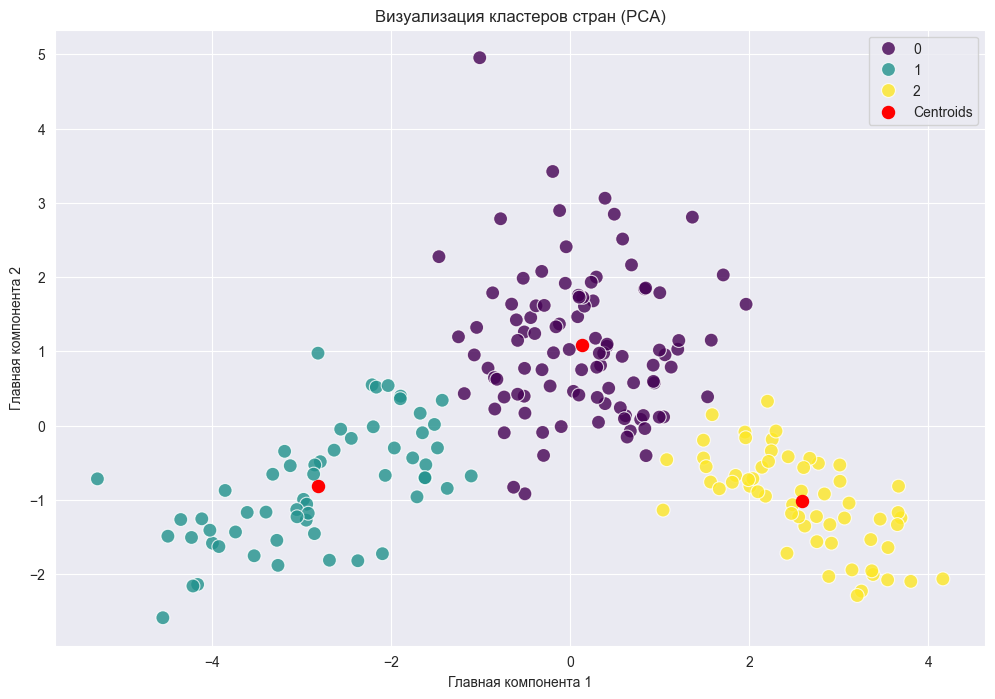

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

centroids_pca = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(12, 8))

sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=labels,
    palette='viridis',
    s=100,
    alpha=0.8
)

plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    marker='.',
    s=300,
    c='red',
    label='Centroids'
)

plt.title('Визуализация кластеров стран (PCA)')
plt.xlabel('Главная компонента 1')
plt.ylabel('Главная компонента 2')
plt.legend()
plt.grid(True)
plt.show()

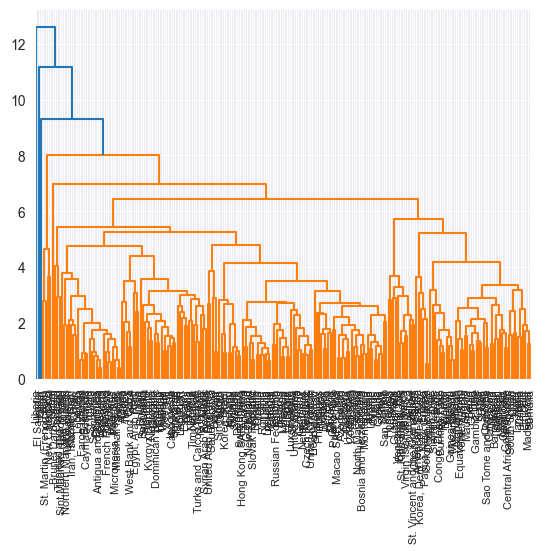

In [61]:
merging = linkage(X, method='weighted')

dendrogram(merging, labels=df.index, leaf_rotation=90, leaf_font_size=8)
plt.show()

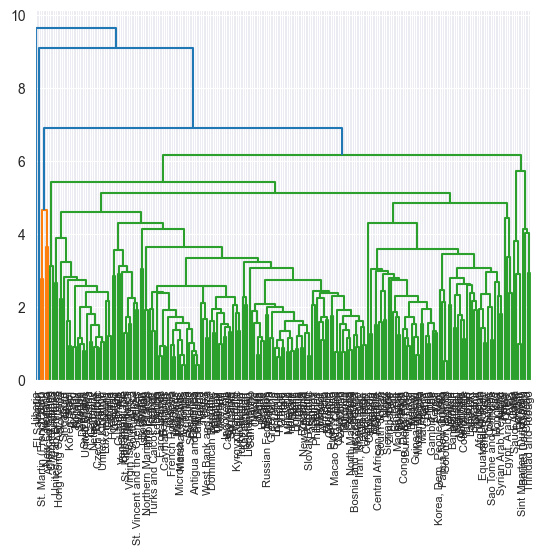

In [62]:
merging = linkage(X, method='average')

dendrogram(merging, labels=df.index, leaf_rotation=90, leaf_font_size=8)
plt.show()

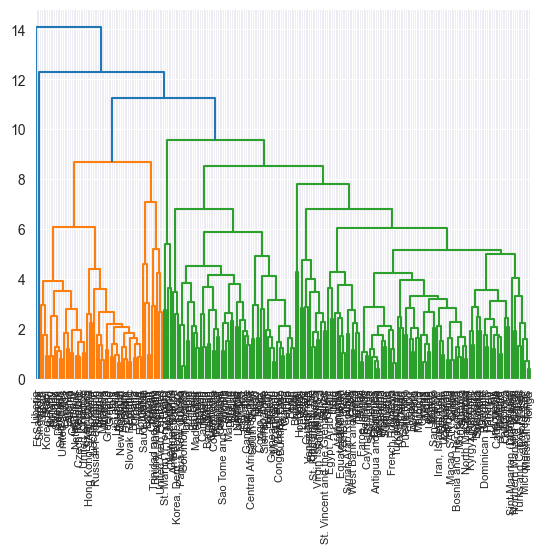

In [63]:
merging = linkage(X, method='complete')

dendrogram(merging, labels=df.index, leaf_rotation=90, leaf_font_size=8)
plt.show()